# Cybersecurity Attacks Dataset - Exploratory Data Analysis & Modeling Feasibility

This Jupyter Notebook provides a comprehensive Exploratory Data Analysis (EDA) on the **Cybersecurity Attacks** dataset. Our primary goals are:
1. **Data Inspection & Cleaning**: Understand data types, missing values, distributions, and summary statistics.
2. **Feature Engineering & Visualization**: Uncover correlations, patterns, and anomalies in network traffic.
3. **Modeling Feasibility Assessment**: Evaluate what machine learning models can be built (Classification, Regression, Unsupervised Learning).
4. **Train/Validation/Test Splitting**: Demonstrate proper data splitting strategies for supervised machine learning pipelines.

In [2]:
# Import necessary libraries
%pip install pandas numpy matplotlib seaborn scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Styling setup
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

  Using cached pandas-3.0.5-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.5.2-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.11.1-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.9.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached tzdata-2026.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached scipy-1.18.1-cp314-cp314-win_amd64.whl.metadata (61 kB)
  Using cached narwhals-2.25.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached pandas-3.0.5-cp314-cp314-win_amd64.whl (10.0 MB)
Using cached numpy-2.5.2-cp

## 1. Load and Inspect the Dataset

First, we load the dataset and examine its dimensions, column types, and initial rows to understand the structure of the data.

In [3]:
# Load dataset
df = pd.read_csv('cybersecurity_attacks.csv')

# Display basic info
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (40000, 25)


,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Payload Data,...,Action Taken,Severity Level,User Information,Device Information,Network Segment,Geo-location Data,Proxy Information,Firewall Logs,IDS/IPS Alerts,Log Source
0,2023-05-30 06:33:58,103.216.15.12,84.9.164.252,31225,17616,ICMP,503,Data,HTTP,Qui natus odio asperiores nam. Optio nobis ius...,...,Logged,Low,Reyansh Dugal,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment A,"Jamshedpur, Sikkim",150.9.97.135,Log Data,NaN,Server
1,2020-08-26 07:08:30,78.199.217.198,66.191.137.154,17245,48166,ICMP,1174,Data,HTTP,Aperiam quos modi officiis veritatis rem. Omni...,...,Blocked,Low,Sumer Rana,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment B,"Bilaspur, Nagaland",NaN,Log Data,NaN,Firewall
2,2022-11-13 08:23:25,63.79.210.48,198.219.82.17,16811,53600,UDP,306,Control,HTTP,Perferendis sapiente vitae soluta. Hic delectu...,...,Ignored,Low,Himmat Karpe,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,Segment C,"Bokaro, Rajasthan",114.133.48.179,Log Data,Alert Data,Firewall
3,2023-07-02 10:38:46,163.42.196.10,101.228.192.255,20018,32534,UDP,385,Data,HTTP,Totam maxime beatae expedita explicabo porro l...,...,Blocked,Medium,Fateh Kibe,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_11_5; ...,Segment B,"Jaunpur, Rajasthan",NaN,NaN,Alert Data,Firewall
4,2023-07-16 13:11:07,71.166.185.76,189.243.174.238,6131,26646,TCP,1462,Data,DNS,Odit nesciunt dolorem nisi iste iusto. Animi v...,...,Blocked,Low,Dhanush Chad,Mozilla/5.0 (compatible; MSIE 5.0; Windows NT ...,Segment C,"Anantapur, Tripura",149.6.110.119,NaN,Alert Data,Firewall


In [4]:
# Check data types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp               40000 non-null  str    
 1   Source IP Address       40000 non-null  str    
 2   Destination IP Address  40000 non-null  str    
 3   Source Port             40000 non-null  int64  
 4   Destination Port        40000 non-null  int64  
 5   Protocol                40000 non-null  str    
 6   Packet Length           40000 non-null  int64  
 7   Packet Type             40000 non-null  str    
 8   Traffic Type            40000 non-null  str    
 9   Payload Data            40000 non-null  str    
 10  Malware Indicators      20000 non-null  str    
 11  Anomaly Scores          40000 non-null  float64
 12  Alerts/Warnings         19933 non-null  str    
 13  Attack Type             40000 non-null  str    
 14  Attack Signature        40000 non-null  str    
 

## 2. Exploratory Data Analysis & Visualizations

Let's explore key columns such as `Attack Type`, `Severity Level`, `Protocol`, and `Anomaly Scores` to understand network characteristics and security threats.

C:\Users\lindb\AppData\Local\Temp\ipykernel_12592\3339026388.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Attack Type', palette='viridis')


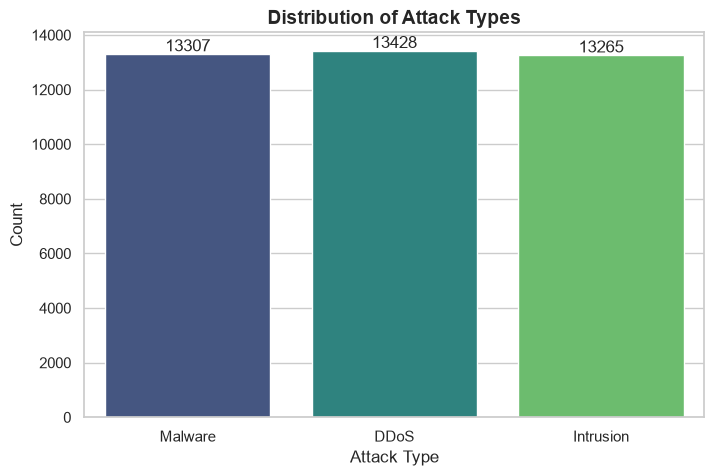

In [5]:
# Distribution of Attack Types
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Attack Type', palette='viridis')
plt.title('Distribution of Attack Types', fontsize=14, fontweight='bold')
plt.xlabel('Attack Type')
plt.ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

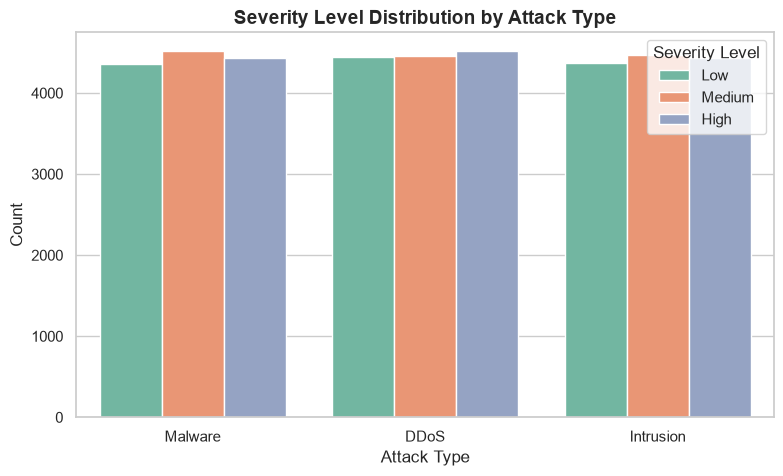

In [6]:
# Distribution of Severity Levels across Attack Types
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x='Attack Type', hue='Severity Level', palette='Set2')
plt.title('Severity Level Distribution by Attack Type', fontsize=14, fontweight='bold')
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.legend(title='Severity Level')
plt.show()

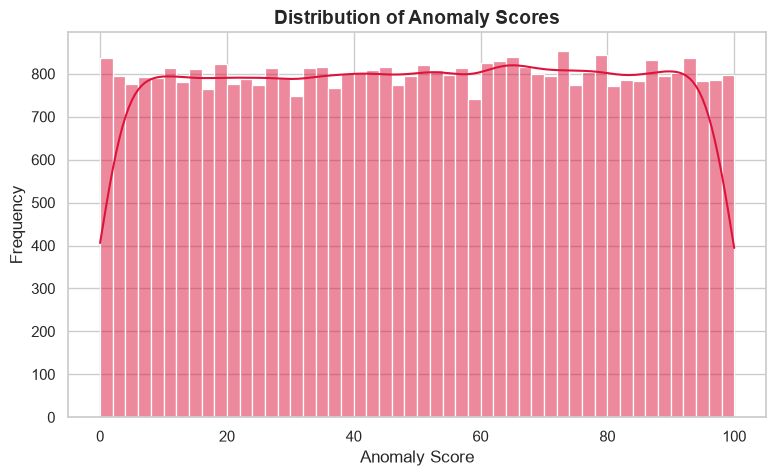

In [7]:
# Anomaly Scores Distribution
plt.figure(figsize=(9, 5))
sns.histplot(df['Anomaly Scores'], kde=True, color='crimson', bins=50)
plt.title('Distribution of Anomaly Scores', fontsize=14, fontweight='bold')
plt.xlabel('Anomaly Score')
plt.ylabel('Frequency')
plt.show()

## 3. Modeling Feasibility Assessment

Based on the structure and contents of this dataset, we can evaluate three main categories of machine learning tasks:

### 1. Classification Modeling
- **Target 1**: `Attack Type` (Multi-class: DDoS, Malware, Intrusion)
- **Target 2**: `Severity Level` (Multi-class/Ordinal: Low, Medium, High)
- **Target 3**: `Action Taken` (Multi-class: Blocked, Ignored, Logged)
- **Feasibility**: **High**. Features include numerical properties (`Packet Length`, `Source Port`, `Destination Port`, `Anomaly Scores`) and categorical properties (`Protocol`, `Traffic Type`, `Network Segment`).

### 2. Regression Modeling
- **Target**: `Anomaly Scores` (Continuous floating-point values)
- **Feasibility**: **High**. We can predict anomaly scores using packet characteristics, protocol types, and network segments.

### 3. Unsupervised Learning & Anomaly Detection
- **Task**: Clustering network flows (K-Means, DBSCAN) or detecting outliers (Isolation Forest, One-Class SVM) on numerical features (`Packet Length`, `Anomaly Scores`, ports).
- **Feasibility**: **Moderate to High**.

## 4. Train, Validation, and Test Data Splitting

For supervised learning tasks (e.g., predicting `Attack Type`), it is standard practice to split the dataset into:
- **Training Set (70%)**: Used to train machine learning models.
- **Validation Set (15%)**: Used for hyperparameter tuning and model selection.
- **Test Set (15%)**: Held out completely to evaluate final model generalization.

Below is a robust implementation using `scikit-learn` with stratification to preserve class balance.

In [8]:
from sklearn.model_selection import train_test_split

# Example: Preparing features and target for classification (Predicting 'Attack Type')
feature_cols = ['Source Port', 'Destination Port', 'Packet Length', 'Anomaly Scores']
X = df[feature_cols]
y = df['Attack Type']

# Step 1: Split into Train (70%) and Temp (30%) with stratification
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Step 2: Split Temp into Validation (15%) and Test (15%) with stratification
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Training set shape: {X_train.shape}, Labels: {y_train.shape}")
print(f"Validation set shape: {X_val.shape}, Labels: {y_val.shape}")
print(f"Test set shape: {X_test.shape}, Labels: {y_test.shape}")

Training set shape: (28000, 4), Labels: (28000,)
Validation set shape: (6000, 4), Labels: (6000,)
Test set shape: (6000, 4), Labels: (6000,)


## Summary of Findings
- **Dataset Quality**: Clean structure with 40,000 records.
- **Supervised Modeling**: Excellent candidate for Multi-class Classification (`Attack Type`, `Severity Level`) and Regression (`Anomaly Scores`).
- **Best Practice**: Use stratified splitting to maintain class proportions across train, validation, and test splits.

Yes, it is entirely possible to perform the types of modeling discussed. The dataset has a structure that fits these three main tracks well:

**Classification:**
- **Target Variables to Predict:** `Attack Type`(DDoS, Malware, Intrusion), `Severity Level`(Low, Medium, High), or `Action Taken`(Blocked, Ignored, Logged).

- **Why it works:** You have clear categorical outcomes and a variety of numerical and categorical features (`Packet Length`, `Source Port`, `Destination Port`, `Protocol`, `Traffic Type`, `Network Segment`, and `Anomaly Scores`) that serve as excellent predictors.

**Regression:**
- **Target Variable to Predict:** `Anomaly Scores` (which are continuous floating-point values).

- **Why it works:** You can use packet size, ports, protocols, and network segments to train a regression model (such as a Random Forest Regressor or XGBoost) to calculate or estimate the anomaly score.

**Unsupervised Learning / Anomaly Detection:**

- **Use case:** Clustering network traffic (e.g., K-Means or DBSCAN) or pure outlier detection (e.g., Isolation Forest or One-Class SVM) based on numerical patterns like `Packet Length`, ports, and `Anomaly Scores`.

All of these tasks can be set up using standard libraries like `scikit-learn` in your Jupyter Notebook, where it is recommended to split the data into train (70%), validation (15%), and test (15%) for the supervised models.